In [145]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [146]:
import numpy as np
import pandas as pd
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
from openai import OpenAI
import os
import openai

In [147]:
path = '/content/drive/MyDrive/Colab Notebooks/AI_survey_student.xlsx'
df = pd.read_excel(path)

In [148]:
os.environ["OPENAI_API_KEY"] = ""

client = OpenAI()

In [149]:
import re

# Define a dictionary to map current column names to new, shorter names for the student survey
new_column_names = {
    '타임스탬프': 'Timestamp',
    '1. Have you used AI for academic purpose (assignments, reasearch, papers)? \nAl를 학업(과제, 논문, 연구 등)에 활용해본 경험이 있나요?': 'AI_academic_use',
    '2. Has AI improved your research productivity? \n AI의 도움으로 연구 효율이 향상되었다고 느끼나요?': 'AI_productivity_impact',
    '3. Do you think submitting AI-generated work (text, data, code) is unethical?\nAI의 결과(글, 데이터, 코드 등)를 그대로 제출하는 것은 윤리적으로 문제 있다고 생각하나요?': 'AI_unethical_submission',
    '4. Does AI improve the quality of academic writing?\nAI가 학문적 글쓰기의 질을 향상시킨다고 생각하나요?': 'AI_writing_quality',
    '5. Have you ever encountered false information or fake citations generated by AI?\nAI를 사용하면서 허위 정보나 잘못된 인용을 본 적이 있나요?': 'AI_false_info',
    '6. Do you think AI supports or replace human creativity? \nAl는 인간의 창의적 사고를 \'보조\'한다고 생각하나요, \'대체\'한다고 생각하나요?': 'AI_creativity_role',
    '7. Do you think AI -generated content requires proper citation or acknowledgement?\nAI 사용 시 인용•출처 표기가 필요하다고 생각하나요?': 'AI_resource',
    '8. Should universities set clear policies about AI use and plagiarism? \n대학은 AI 관련 정책(허용 범위, 표절 기준)을 명확히 해야 한다고 생각하나요?': 'AI_policy',
    '9. What do you think is the greatest advantage of using AI?\nAI 활용의 가장 큰 장점은 무엇이라고 생각하나요?': 'AI_benefit',
    '10. How do you AI will change the future of higher education?\nAI가 고등교육의 미래를 어떻게 바꿀 것이라고 생각하나요?': 'AI_future_education'
}

# Rename the columns using the mapping
df = df.rename(columns=new_column_names)

# Function to clean string values by removing text after '/'
def clean_string_values(df):
    for column in df.columns:
        if df[column].dtype == 'object':  # Check if the column contains string data
            df[column] = df[column].astype(str).apply(lambda x: re.split(' / ', x)[0].strip() if ' / ' in x else x)
    return df

# Apply the cleaning function to the DataFrame
df = clean_string_values(df)

# Display the first few rows with the cleaned values
display(df.head())

,Timestamp,AI_academic_use,AI_productivity_impact,AI_unethical_submission,AI_writing_quality,AI_false_info,AI_creativity_role,AI_resource,AI_policy,AI_benefit,AI_future_education
0,2025-10-26 17:59:20.485,Sometimes,Agree,Somewhat unethical,Disagree,Sometimes,Both,Neutral,Agree,"정확하든 아니든, 빠르고 효율적으로 정보를 얻고 이를 활용 가능함.","사용하기에 달렸지만, 부정적인 방향으로 바뀔 가능성이 높다고 생각한다."
1,2025-10-26 18:00:46.495,Sometimes,Strongly agree,Depends on context,Agree,Sometimes,Mostly support,Agree,Neutral,편함,편하게
2,2025-10-26 18:10:59.815,Never,Disagree,Somewhat unethical,Neutral,Rarely,Mostly support,Strongly agree,Disagree,to get good insights,I think it will get rid of pointless jobs.
3,2025-10-26 18:16:39.588,Sometimes,Agree,Somewhat unethical,Agree,Sometimes,Both,Agree,Disagree,No,improve mor idea
4,2025-10-26 18:30:48.392,Frequently,Agree,Clearly unethical,Neutral,Often,Mostly support,Agree,Agree,내 사고의 검증,자기주도적으로


In [150]:
def batch_translate(texts, model="gpt-4o-mini"):
    valid_items = [(i, text) for i, text in enumerate(texts) if pd.notna(text) and text != '']
    if not valid_items:
        return texts

    indices, valid_texts = zip(*valid_items)

    combined_query = "\n".join([f"{i}: {text}" for i, text in enumerate(valid_texts)])

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "Translate the following Korean sentences to English. Maintain the format 'Number: Translated Text' and return each on a new line. Do not add any other text."},
            {"role": "user", "content": combined_query}
        ],
        temperature=0
    )

    translated_raw = response.choices[0].message.content.strip().split('\n')
    translated_dict = {}
    for line in translated_raw:
        try:
            parts = line.split(': ', 1)
            if len(parts) == 2:
                translated_dict[int(parts[0])] = parts[1]
        except:
            continue

    results = list(texts)
    for i, original_idx in enumerate(indices):
        results[original_idx] = translated_dict.get(i, valid_texts[i])

    return results

print("AI_benefit 번역 중...")
df['AI_benefit'] = batch_translate(df['AI_benefit'].tolist())

print("AI_future_education 번역 중...")
df['AI_future_education'] = batch_translate(df['AI_future_education'].tolist())

display(df[['AI_benefit', 'AI_future_education']].head())

AI_benefit 번역 중...
AI_future_education 번역 중...


,AI_benefit,AI_future_education
0,"Whether accurate or not, it allows for quick a...","It depends on how it is used, but I think ther..."
1,Convenience,Comfortably
2,to get good insights,I think it will get rid of pointless jobs.
3,No,Improve more ideas
4,Verification of my thoughts,Self-directed


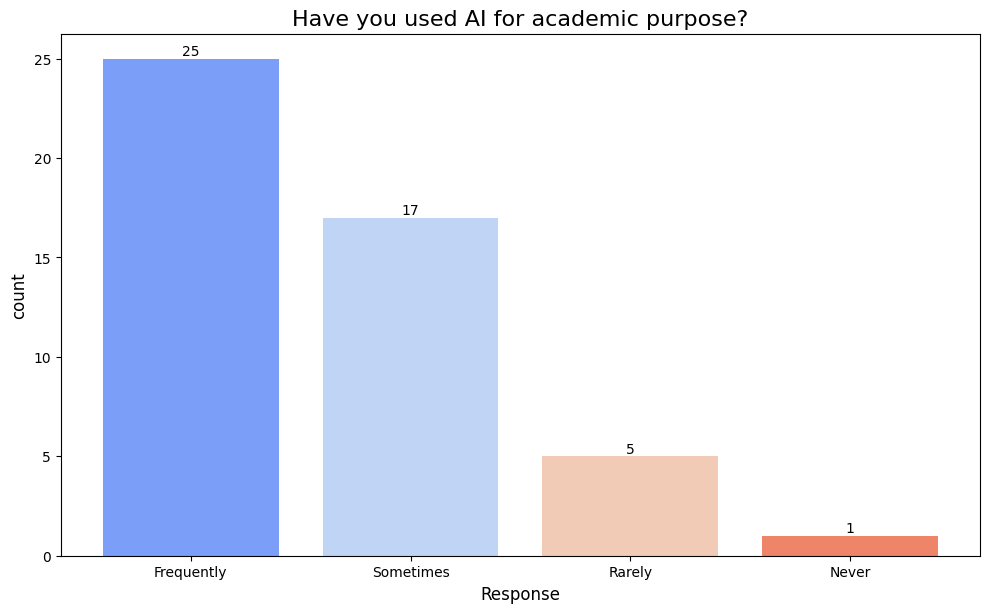

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts and sort them in descending order
academic_use = df['AI_academic_use'].value_counts().sort_values(ascending=False)

# Create a bar plot using matplotlib with improved aesthetics
plt.figure(figsize=(10, 6)) # Set a good figure size
plt.bar(academic_use.index, academic_use.values, color=sns.color_palette("coolwarm", len(academic_use)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Have you used AI for academic purpose?", fontsize=16)
plt.ylabel("count", fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.xlabel("Response", fontsize=12)
plt.show()

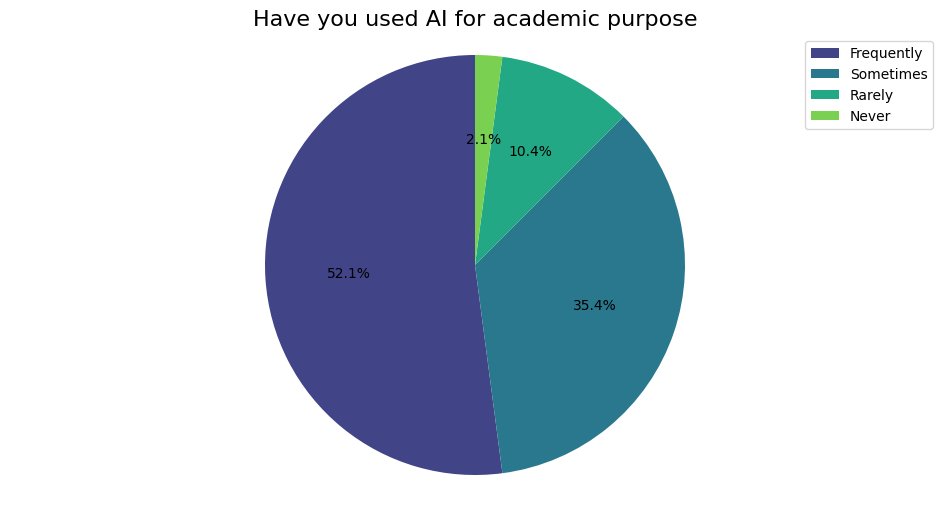

In [152]:
# with pie chart
plt.figure(figsize=(12, 6))
plt.pie(academic_use.values, colors=sns.color_palette("viridis", len(academic_use)), autopct='%1.1f%%', startangle=90)
plt.title("Have you used AI for academic purpose", fontsize=16)
plt.axis('equal')
plt.legend(labels=academic_use.index, loc='upper right')
plt.show()

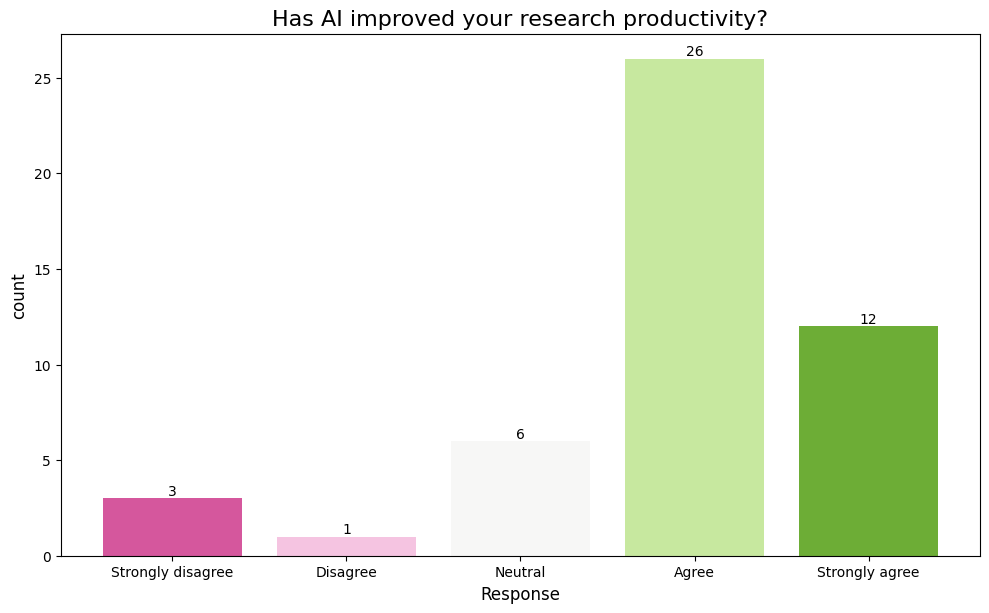

In [153]:
# Calculate the value counts
productivity_impact = df['AI_productivity_impact'].value_counts()

# Define a custom order
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order
productivity_impact = productivity_impact.reindex(custom_order, fill_value=1)

# Create a bar plot using matplotlib with improved aesthetics
plt.figure(figsize=(10, 6)) # Set a good figure size
plt.bar(productivity_impact.index, productivity_impact.values, color=sns.color_palette("PiYG", len(productivity_impact)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Has AI improved your research productivity?", fontsize=16)
plt.ylabel("count", fontsize=12)
plt.tight_layout()
plt.xlabel("Response", fontsize=12)
plt.show()

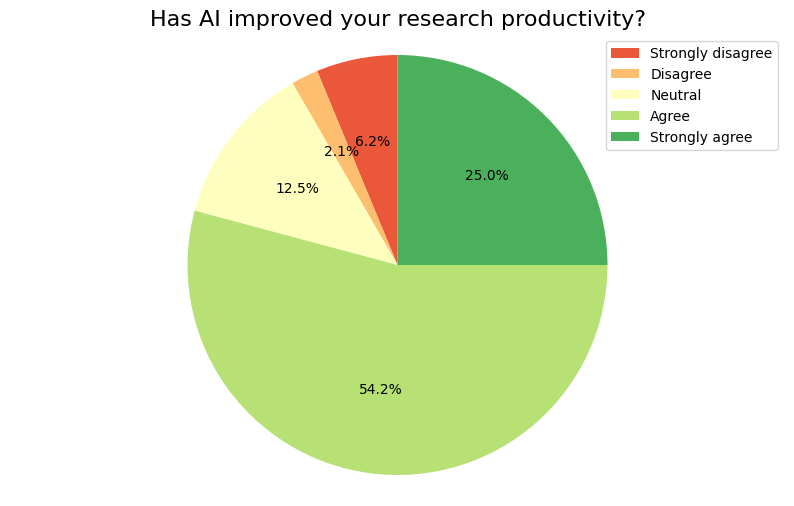

In [154]:
# question 2 pie chart
plt.figure(figsize=(10, 6))
plt.pie(productivity_impact.values, colors=sns.color_palette("RdYlGn", len(productivity_impact)), autopct='%1.1f%%', startangle=90)
plt.title("Has AI improved your research productivity?", fontsize=16)
plt.legend(labels=productivity_impact.index, loc='upper right')
plt.axis('equal')
plt.show()

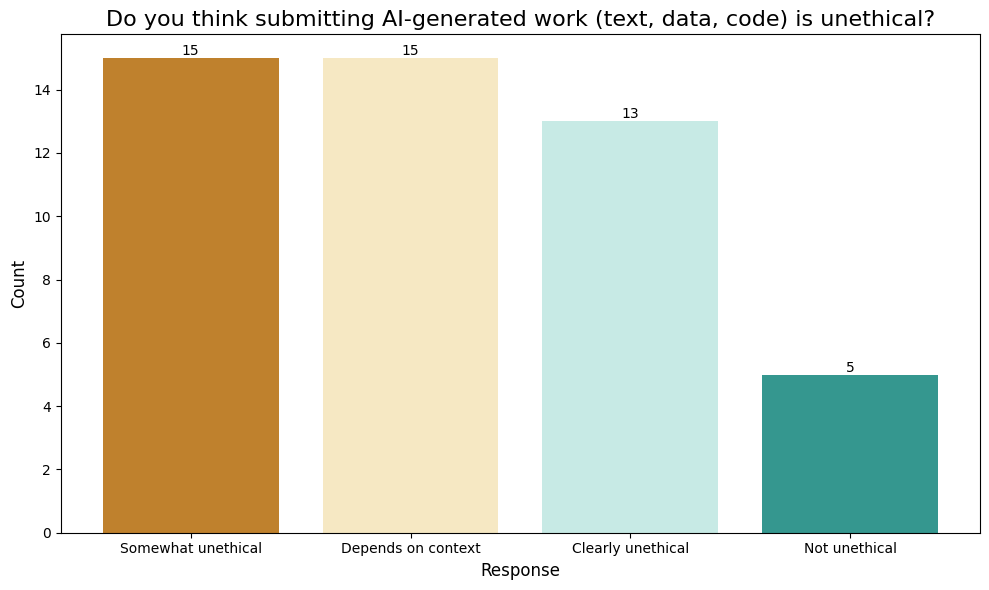

In [155]:
# Question 3
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts
unethical_submission = df['AI_unethical_submission'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(unethical_submission.index, unethical_submission.values, color=sns.color_palette("BrBG", len(unethical_submission)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Do you think submitting AI-generated work (text, data, code) is unethical?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

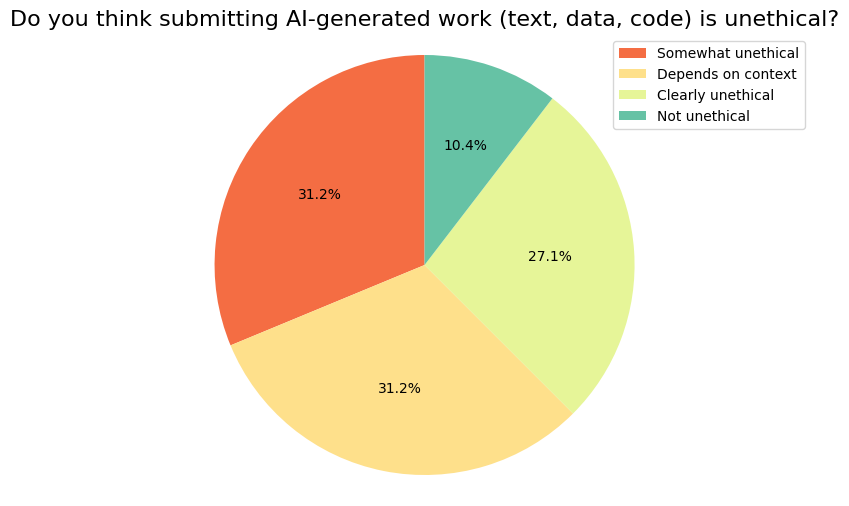

In [156]:
# Create a pie chart
plt.figure(figsize=(10, 6))
plt.pie(unethical_submission.values, colors=sns.color_palette("Spectral", len(unethical_submission)), autopct='%1.1f%%', startangle=90)
plt.title("Do you think submitting AI-generated work (text, data, code) is unethical?", fontsize=16)
plt.legend(labels=unethical_submission.index, loc='upper right')
plt.axis('equal')
plt.show()

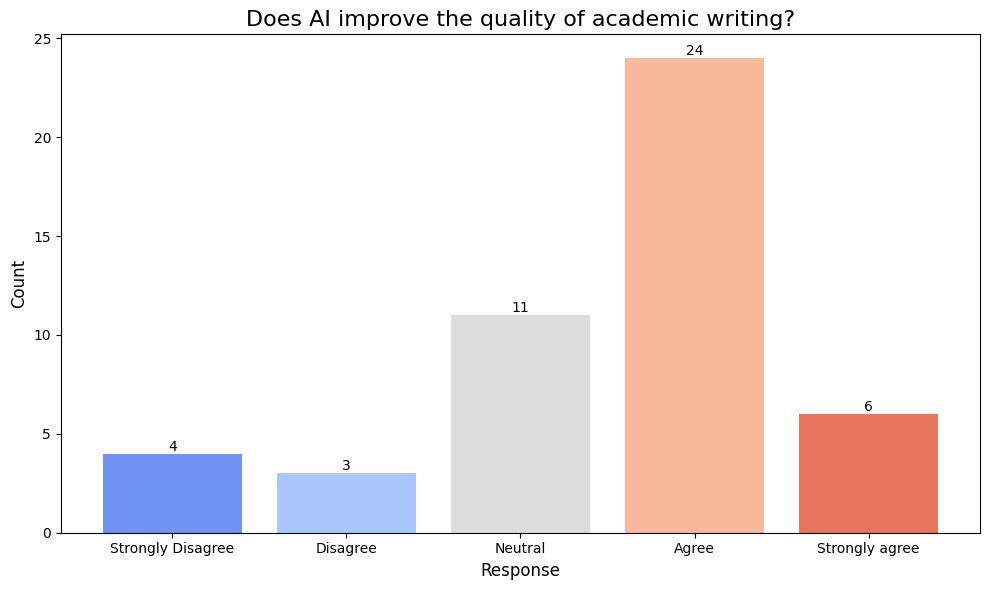

In [157]:
# question 4
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts
writing_quality = df['AI_writing_quality'].value_counts()

# Define a custom order for the categories (Likert scale)
custom_order = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order, filling missing categories with 0
writing_quality = writing_quality.reindex(custom_order, fill_value=0)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(writing_quality.index, writing_quality.values, color=sns.color_palette("coolwarm", len(writing_quality)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Does AI improve the quality of academic writing?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

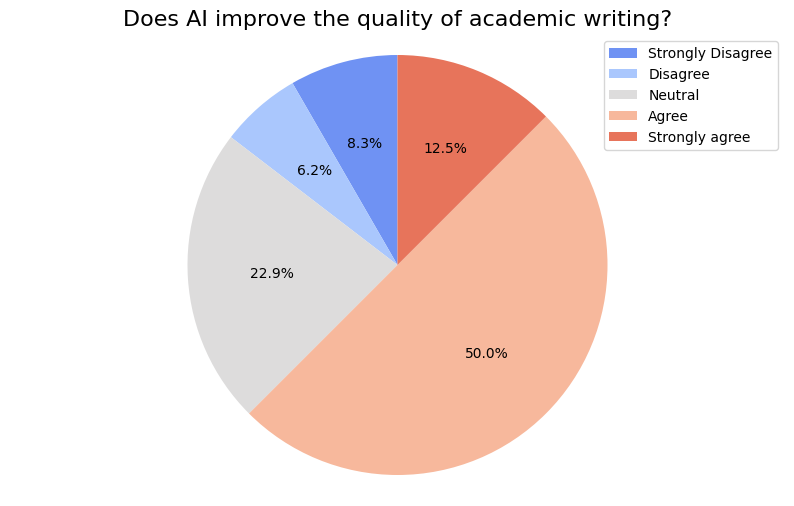

In [158]:
# Create a pie chart
plt.figure(figsize=(10, 6))
plt.pie(writing_quality.values, colors=sns.color_palette("coolwarm", len(writing_quality)), autopct='%1.1f%%', startangle=90)
plt.title("Does AI improve the quality of academic writing?", fontsize=16)
plt.legend(labels=writing_quality.index, loc='upper right')
plt.axis('equal')
plt.show()

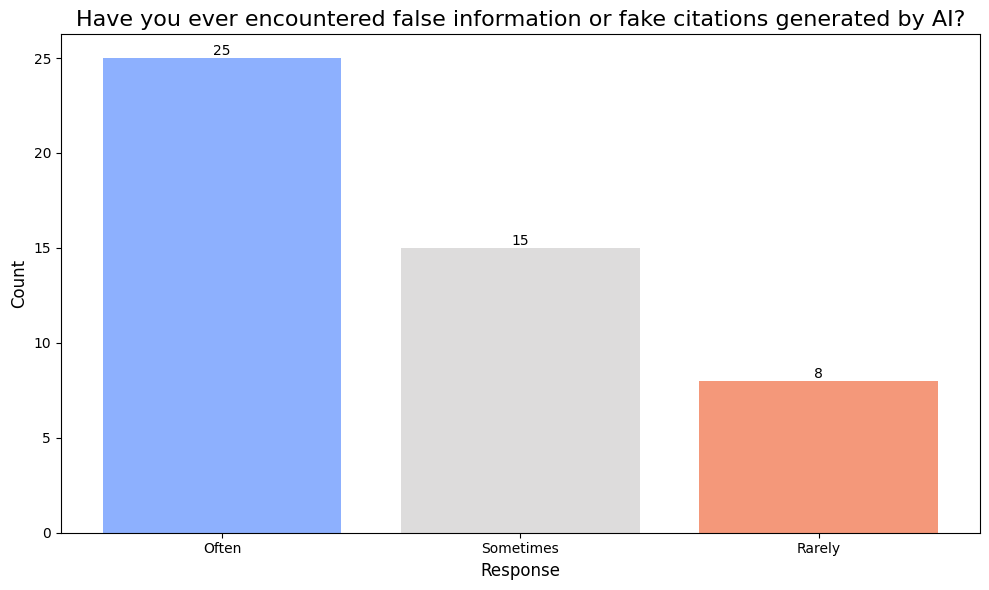

In [159]:
# Question 5
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts
false_info = df['AI_false_info'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(false_info.index, false_info.values, color=sns.color_palette("coolwarm", len(false_info)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Have you ever encountered false information or fake citations generated by AI?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

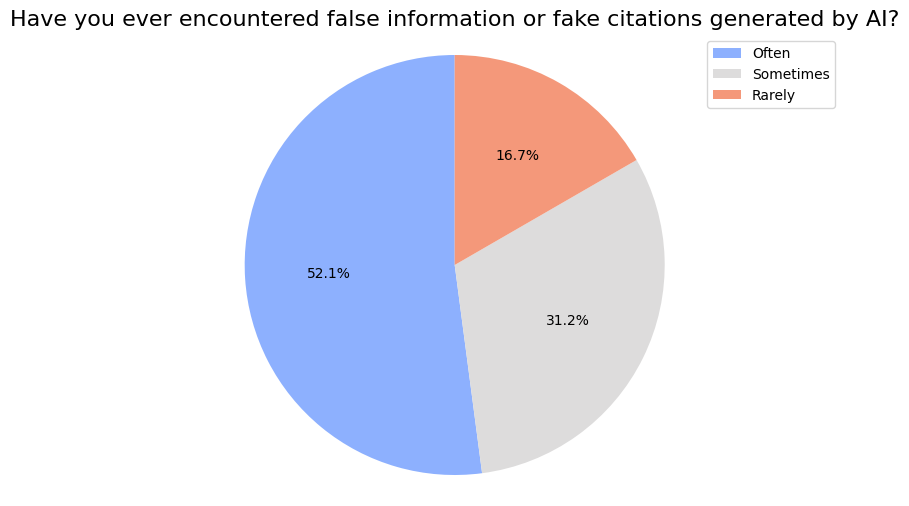

In [160]:

plt.figure(figsize=(10, 6))
plt.pie(false_info.values, colors=sns.color_palette("coolwarm", len(false_info)), autopct='%1.1f%%', startangle=90)
plt.title("Have you ever encountered false information or fake citations generated by AI?", fontsize=16)
plt.legend(labels=false_info.index, loc='upper right')
plt.axis('equal')
plt.show()

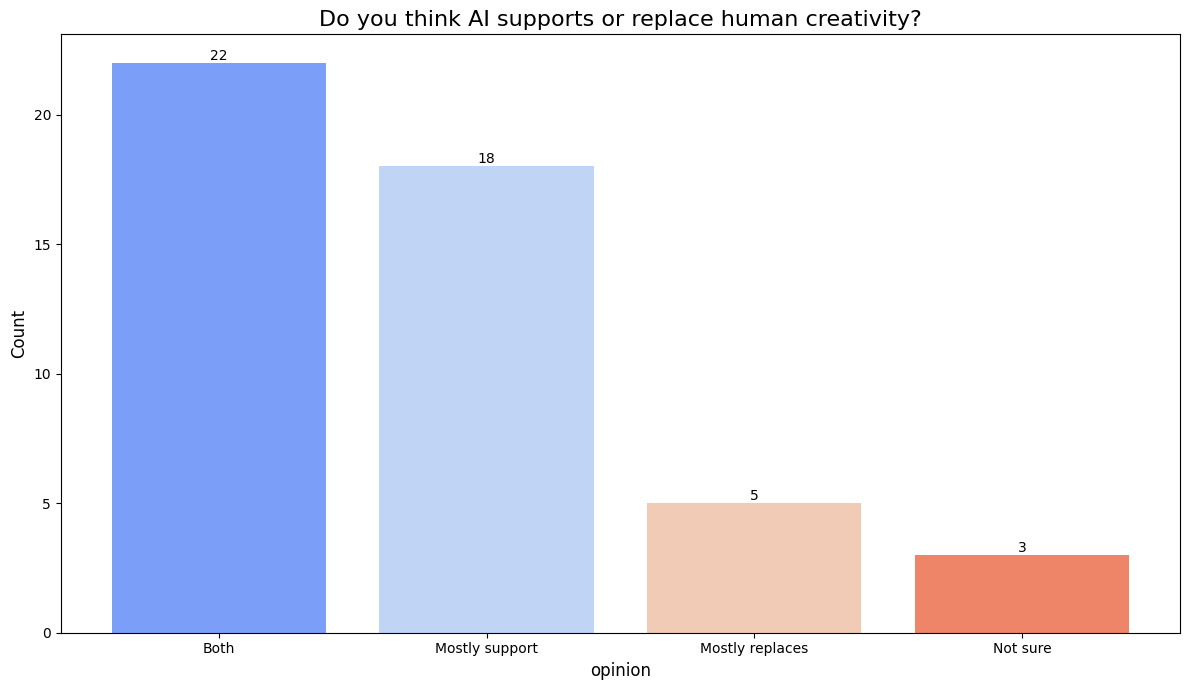

In [161]:
# Question 6
import matplotlib.pyplot as plt
import seaborn as sns

creativity_role = df['AI_creativity_role'].value_counts()

plt.figure(figsize=(12, 7))
plt.bar(creativity_role.index, creativity_role.values, color=sns.color_palette("coolwarm", len(creativity_role)))

plt.bar_label(plt.gca().containers[0])

plt.title("Do you think AI supports or replace human creativity?", fontsize=16)
plt.xlabel("opinion", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

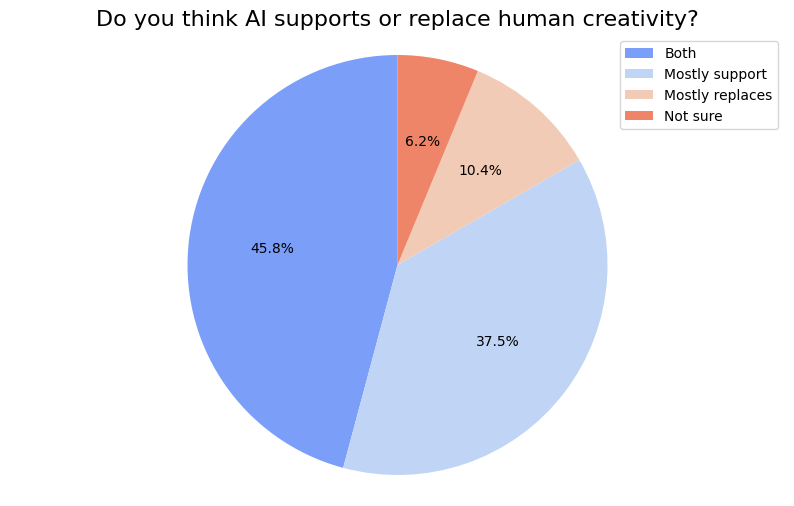

In [162]:
# Pie chart for Question 6
plt.figure(figsize=(10, 6))
plt.pie(creativity_role.values, colors=sns.color_palette("coolwarm", len(creativity_role)), autopct='%1.1f%%', startangle=90)
plt.title("Do you think AI supports or replace human creativity?", fontsize=16)
plt.legend(labels=creativity_role.index, loc='upper right')
plt.axis('equal')
plt.show()

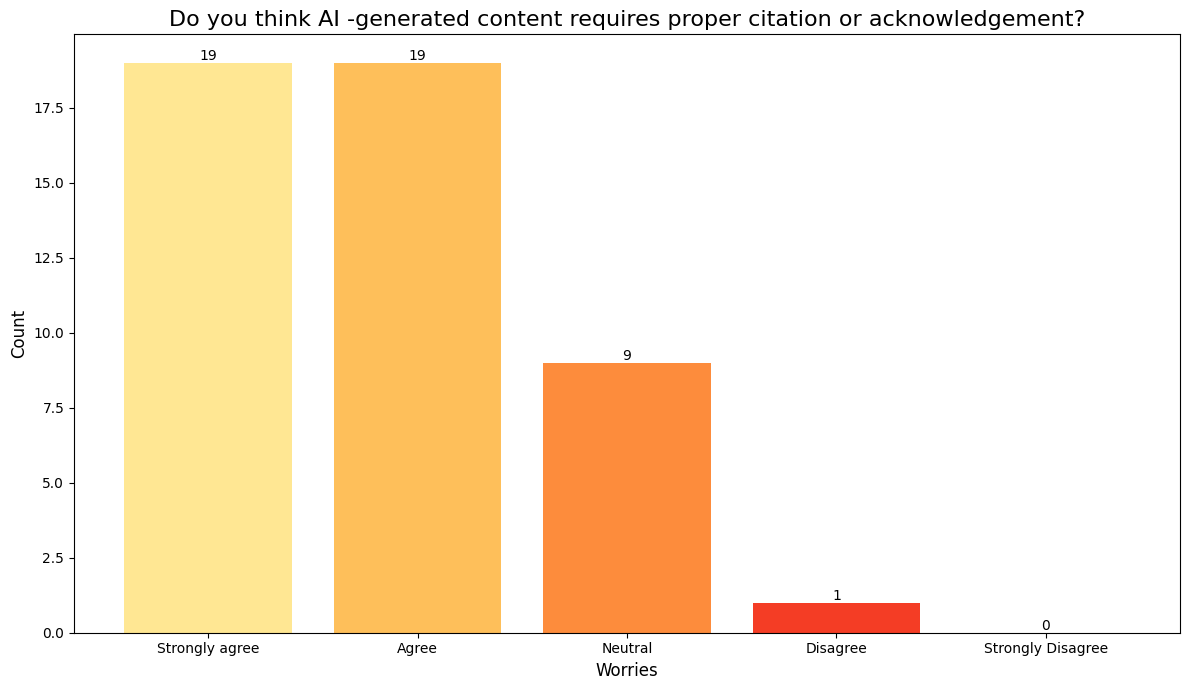

In [163]:
# Question 7
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts
resource = df['AI_resource'].value_counts()

custom_order = ['Strongly agree', 'Agree', 'Neutral', 'Disagree', 'Strongly Disagree']

resource = resource.reindex(custom_order, fill_value=0)

# Create a bar plot
plt.figure(figsize=(12, 7))
plt.bar(resource.index, resource.values, color=sns.color_palette("YlOrRd", len(resource)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Do you think AI -generated content requires proper citation or acknowledgement?", fontsize=16)
plt.xlabel("Worries", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

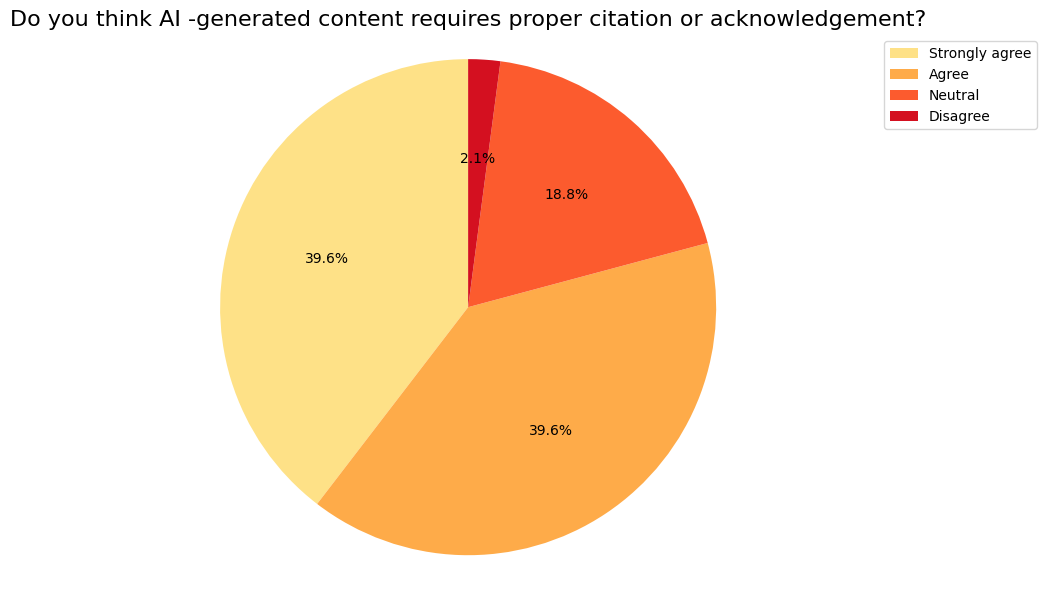

In [164]:
# Create a pie chart for AI_Worries
custom_order = ['Strongly agree', 'Agree', 'Neutral', 'Disagree']

resource = resource.reindex(custom_order, fill_value=0)

plt.figure(figsize=(10, 6))
plt.pie(resource.values, colors=sns.color_palette("YlOrRd", len(resource)), autopct='%1.1f%%', startangle=90)
plt.title("Do you think AI -generated content requires proper citation or acknowledgement?", fontsize=16)
plt.legend(labels=resource.index, loc='upper right', bbox_to_anchor=(1.2, 1)) # Adjust legend position to avoid overlapping
plt.axis('equal')
plt.tight_layout()
plt.show()

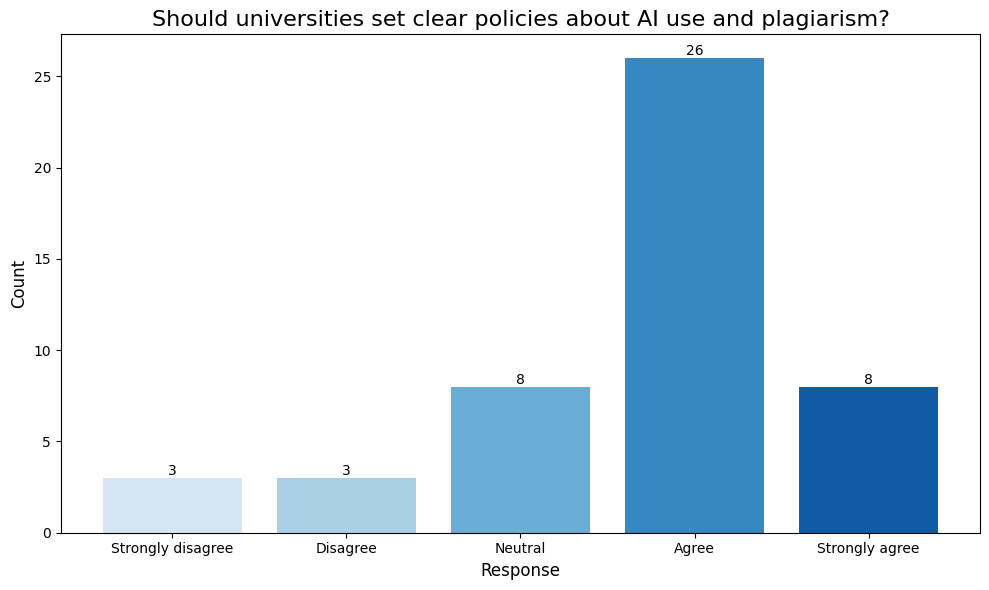

In [165]:
# Question 8
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for AI_Education_expand
policy = df['AI_policy'].value_counts()

# Define a custom order for the categories (Likert scale)
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order, filling missing categories with 0
policy = policy.reindex(custom_order, fill_value=0)

# Create a bar plot for AI_Education_expand
plt.figure(figsize=(10, 6))
plt.bar(policy.index, policy.values, color=sns.color_palette("Blues", len(policy)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Should universities set clear policies about AI use and plagiarism?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

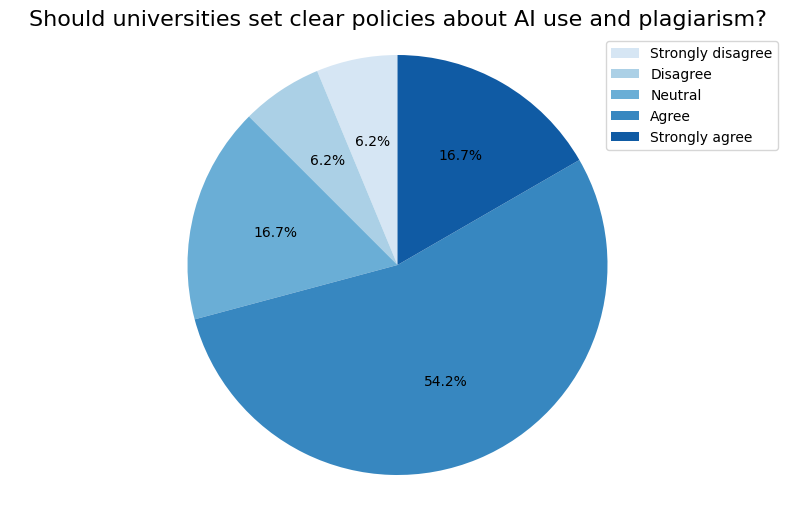

In [166]:
# Create a pie chart for AI_Education_expand
plt.figure(figsize=(10, 6))
plt.pie(policy.values, colors=sns.color_palette("Blues", len(policy)), autopct='%1.1f%%', startangle=90)
plt.title("Should universities set clear policies about AI use and plagiarism?", fontsize=16)
plt.legend(labels=policy.index, loc='upper right')
plt.axis('equal')
plt.show()

In [167]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

custom_word = {
    ',', '.', 'the', 'and', 'this', 'that', 'from', 'your', 'will', 'you',
    'for', 'its', 'their', 'here', 'there', 'when', 'while', '’', 's', '’s',
    'throughout', 'around', 'into', 'onto', 'upon', 'about', 'above', 'below',
    'shall', 'should', 'would', 'is', 'are', 'was', 'were', 'be',
    'an', 'a', 'of', 'to', 'in', 'on', 'at', 'by', 'or', "listings", "*"
}

nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [168]:
# Question 9 Processing

df['AI_benefit'] = df['AI_benefit'].fillna('')
df['AI_benefit'] = df[(df['AI_benefit'] != ".") & (df['AI_benefit'] != "-")]['AI_benefit']

lemmatizer = WordNetLemmatizer()

processed_benefit_texts = []

for text_entry in df['AI_benefit']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    processed_text = ' '.join(filtered_and_lemmatized_tokens)

    processed_benefit_texts.append(processed_text)

In [169]:
# Question 10 Processing
df['AI_future_education'] = df['AI_future_education'].fillna('')
df['AI_future_education'] = df[(df['AI_future_education'] != ".") & (df['AI_future_education'] != "-")]['AI_future_education']

lemmatizer = WordNetLemmatizer()

processed_future_education_texts = []

for text_entry in df['AI_future_education']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    processed_text = ' '.join(filtered_and_lemmatized_tokens)

    processed_future_education_texts.append(processed_text)


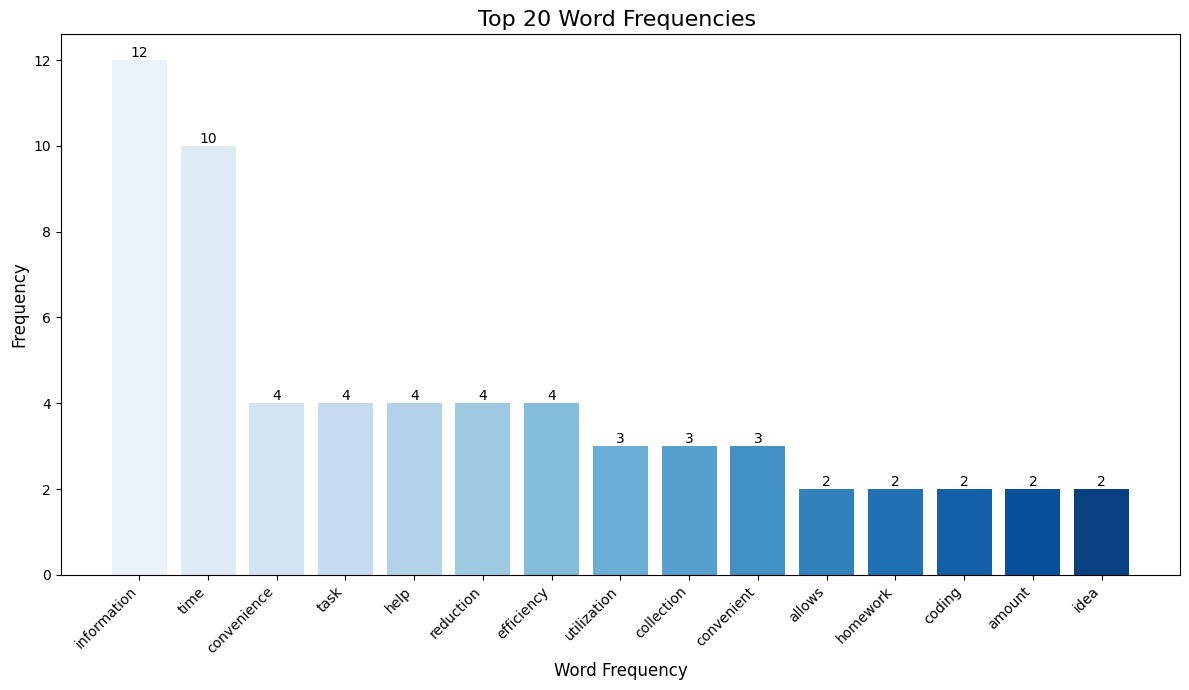

In [170]:
# Question 9 Word Frequency
tagged_education_texts = []
for text in processed_benefit_texts:
  if text.strip():
    tagged_education_texts.append(nltk.pos_tag(nltk.word_tokenize(text)))
noun_data = []
for tagged_text in tagged_education_texts:
    exclude_words = ["ai", "education"]
    nouns = [
        word.lower() for word, tag in tagged_text
        if tag.startswith('N') and word.lower() not in exclude_words
    ]
    noun_data.extend(nouns)

noun_counts = Counter(noun_data)

noun_counts = noun_counts.most_common(15)

plt.figure(figsize=(12, 7))
plt.bar([bigram for bigram, count in noun_counts], [count for bigram, count in noun_counts], color=sns.color_palette("Blues", len(noun_counts)))
plt.xlabel("Word Frequency", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.bar_label(plt.gca().containers[0])
plt.title("Top 20 Word Frequencies ", fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

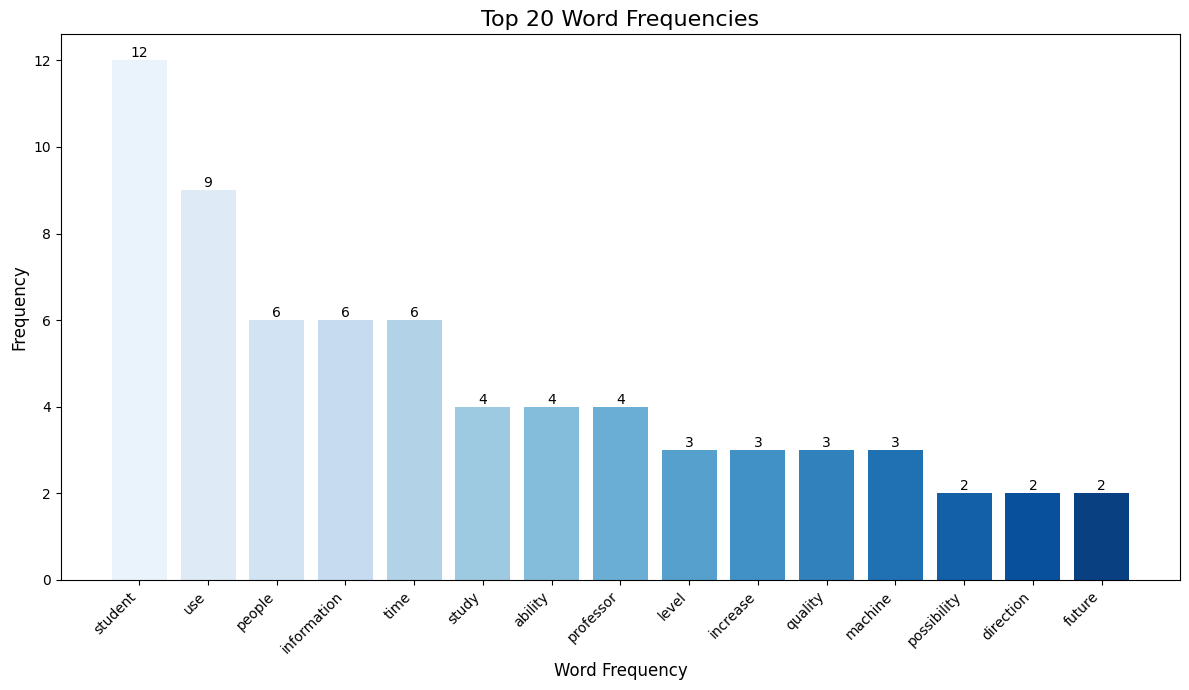

In [171]:
# Question 10 word Freuquncy

tagged_future_education_texts = []
for text in processed_future_education_texts:
  if text.strip():
    tagged_future_education_texts.append(nltk.pos_tag(nltk.word_tokenize(text)))

noun_data = []
for tagged_text in tagged_future_education_texts:
    exclude_words = ["ai", "education"]
    nouns = [
        word.lower() for word, tag in tagged_text
        if tag.startswith('N') and word.lower() not in exclude_words
    ]
    noun_data.extend(nouns)

noun_counts = Counter(noun_data)

noun_counts = noun_counts.most_common(15)

plt.figure(figsize=(12, 7))
plt.bar([bigram for bigram, count in noun_counts], [count for bigram, count in noun_counts], color=sns.color_palette("Blues", len(noun_counts)))
plt.xlabel("Word Frequency", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.bar_label(plt.gca().containers[0])
plt.title("Top 20 Word Frequencies", fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [172]:
# Question 9 Bigram

import networkx as nx

noun_data = [] # Reset noun_data for this calculation

for tagged_text in tagged_education_texts:
    nouns = [
        word.lower() for word, tag in tagged_text
    ]
    noun_data.extend(nouns)

bigrams = list(nltk.bigrams(noun_data))
bigram_counts = Counter(bigrams)

num_top_bigrams = 20
top_n_bigrams = bigram_counts.most_common(num_top_bigrams)

graph_edges = []
graph_nodes = set()

for (word1, word2), count in top_n_bigrams:

    graph_edges.append((word1, word2, {'weight': count}))
    graph_nodes.add(word1)
    graph_nodes.add(word2)

graph_nodes = list(graph_nodes)

G = nx.DiGraph()

G.add_nodes_from(graph_nodes)

G.add_edges_from(graph_edges)

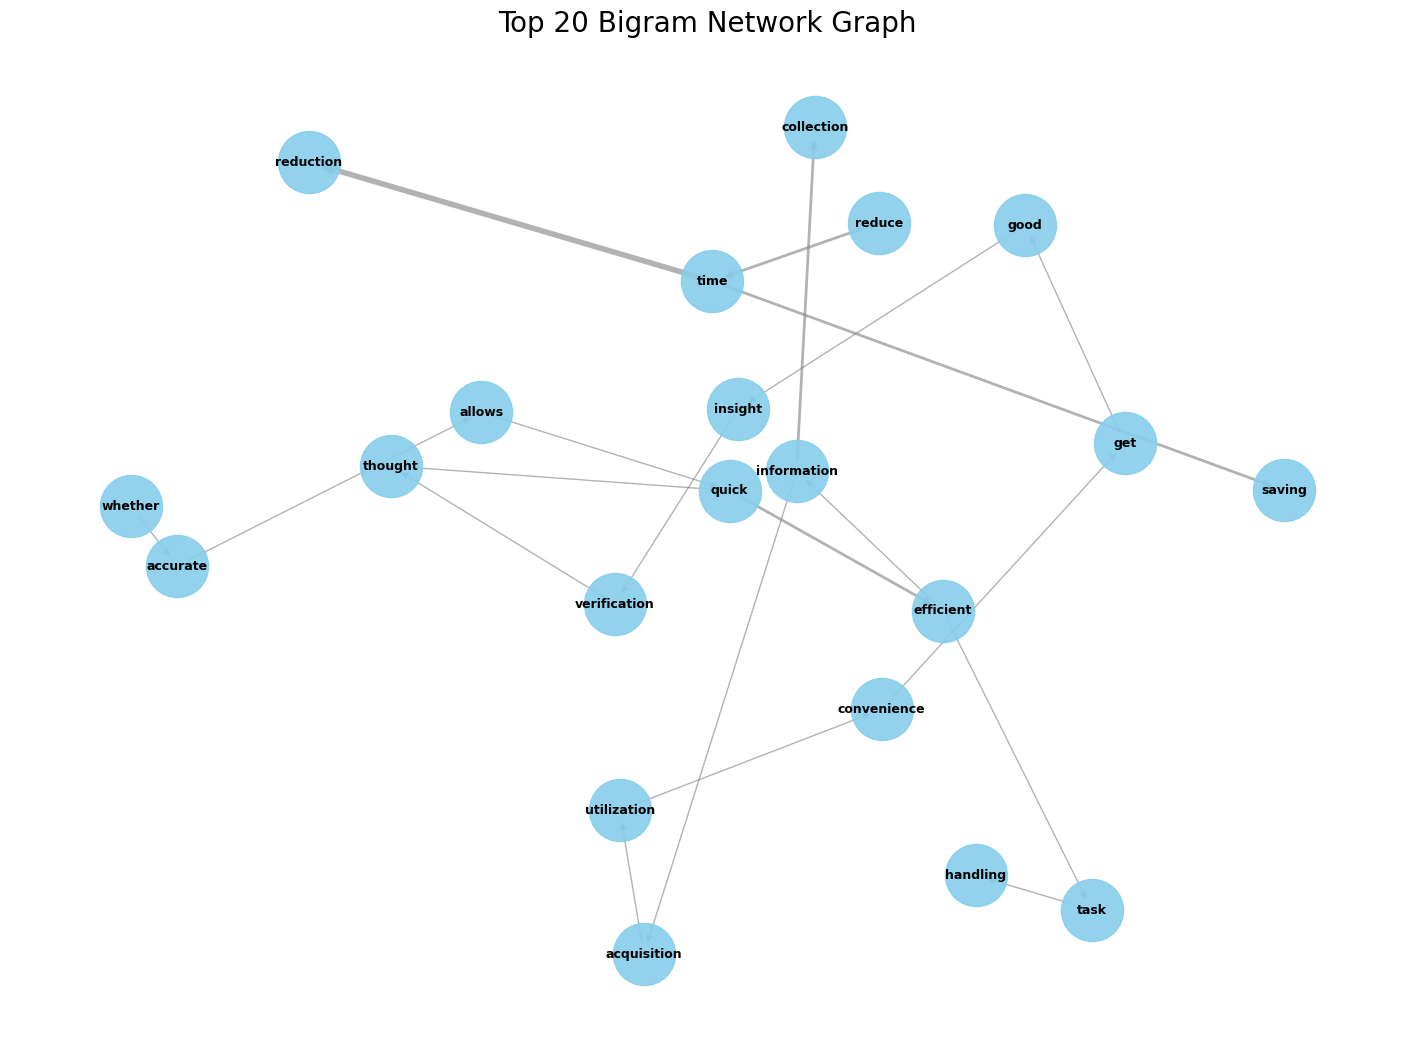

In [173]:
pos = nx.spring_layout(G, k=0.75, iterations=50) # k regulates the distance between nodes

plt.figure(figsize=(18, 13))

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000, alpha=0.9)

edges = G.edges(data=True)
weights = [d['weight'] for u, v, d in edges]

nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Top 20 Bigram Network Graph', size=20)

plt.axis('off')

plt.show()

In [174]:
# Question 10 Bigram

import networkx as nx

noun_data = [] # Reset noun_data for this calculation

for tagged_text in tagged_future_education_texts:
    nouns = [
        word.lower() for word, tag in tagged_text
    ]
    noun_data.extend(nouns)

bigrams = list(nltk.bigrams(noun_data))
bigram_counts = Counter(bigrams)

num_top_bigrams = 20
top_n_bigrams = bigram_counts.most_common(num_top_bigrams)

graph_edges = []
graph_nodes = set()

for (word1, word2), count in top_n_bigrams:

    graph_edges.append((word1, word2, {'weight': count}))
    graph_nodes.add(word1)
    graph_nodes.add(word2)

graph_nodes = list(graph_nodes)

G = nx.DiGraph()

G.add_nodes_from(graph_nodes)

G.add_edges_from(graph_edges)

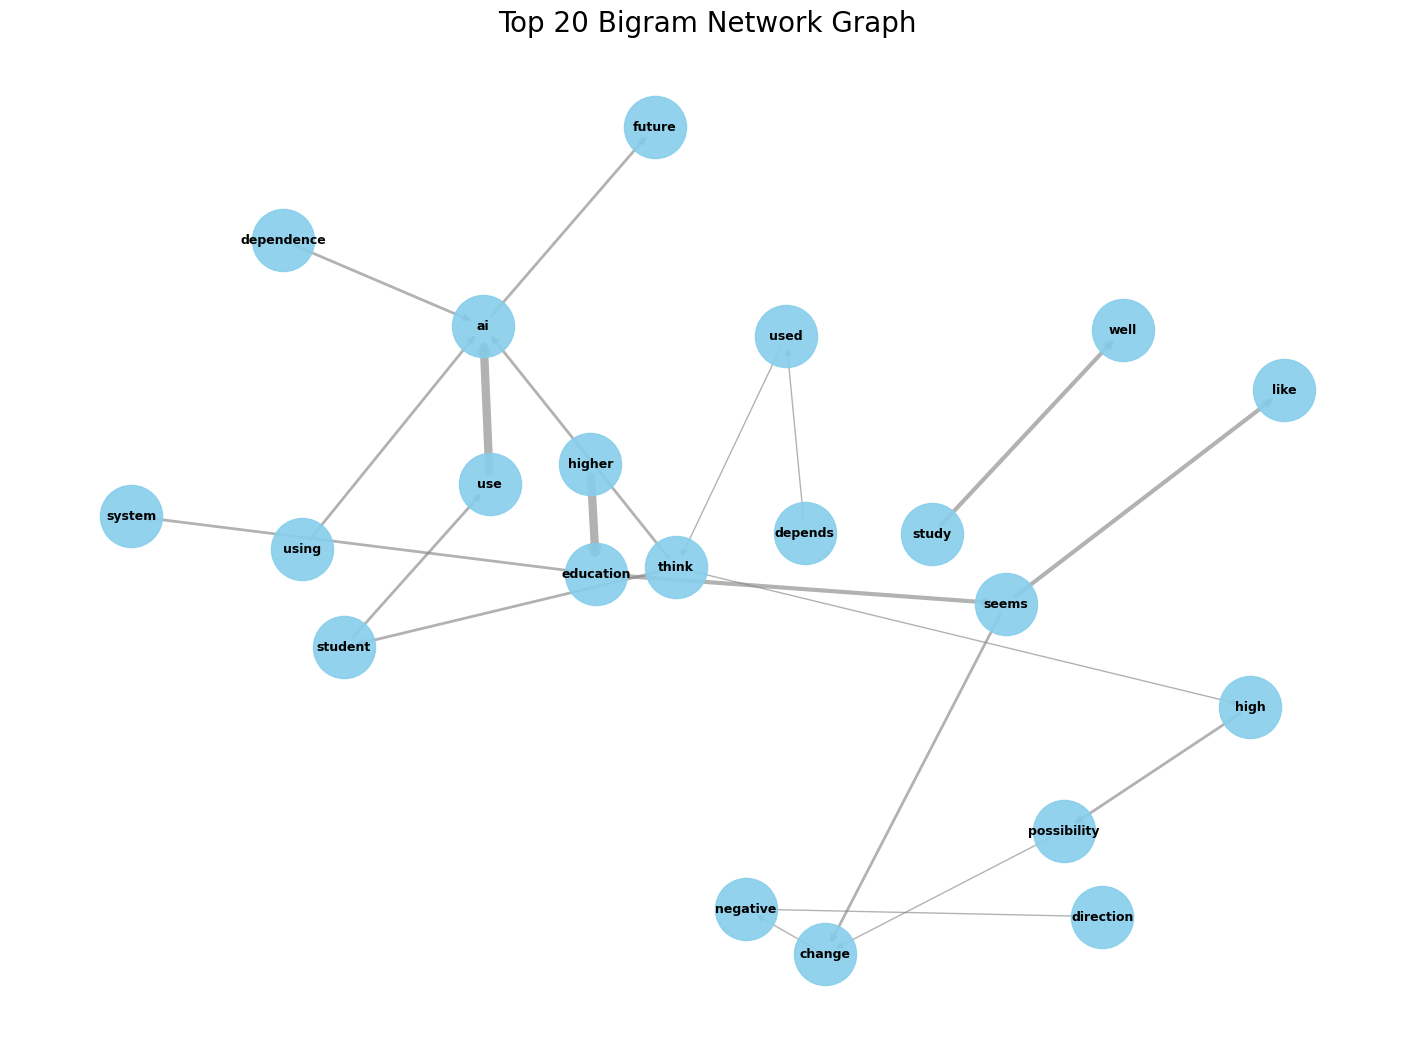

In [175]:
pos = nx.spring_layout(G, k=0.75, iterations=50) # k regulates the distance between nodes

plt.figure(figsize=(18, 13))

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000, alpha=0.9)

edges = G.edges(data=True)
weights = [d['weight'] for u, v, d in edges]

nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Top 20 Bigram Network Graph', size=20)

plt.axis('off')

plt.show()

In [176]:
# bring sentiment wordnote
senti_word_net_path = '/content/drive/MyDrive/Colab Notebooks/SentiWordNet_3.0.0.txt'
senti_word_net = {}

with open(senti_word_net_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue

        parts = line.split('\t')
        if len(parts) < 6:
            continue

        pos = parts[0]
        synset_id = parts[1]
        pos_score = float(parts[2])
        neg_score = float(parts[3])
        synset_terms_str = parts[4]

        synset_terms = synset_terms_str.split(' ')
        for term_entry in synset_terms:
            term = term_entry.split('#')[0].strip()
            if term:
                if term not in senti_word_net:
                    senti_word_net[term] = []
                senti_word_net[term].append({'PosScore': pos_score, 'NegScore': neg_score})

for item, values in senti_word_net.items():
    pos = -1234
    neg = -1234
    for score_dict in values:
        pos_val = score_dict.get('PosScore', 0)
        neg_val = score_dict.get('NegScore', 0)
        pos = max(pos, pos_val)
        neg = max(neg, neg_val)
    values = {'PosScore': pos, 'NegScore': neg}
    senti_word_net[item] = values

In [177]:
# Question 9
lemmatizer = WordNetLemmatizer()

benefit_texts = []

for text_entry in df['AI_benefit']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    benefit_texts.append(filtered_and_lemmatized_tokens)

In [178]:
# Question 9 sentiment result
benefit_sentiment = []

for text in benefit_texts:
  pos = 0
  neg = 0
  for word in text:
    if word in senti_word_net:
      pos += senti_word_net[word]['PosScore']
      neg += senti_word_net[word]['NegScore']
  benefit_sentiment.append(pos-neg)


df['AI_benefit_sentiment_score'] = benefit_sentiment
df['AI_benefit_sentiment'] = ['Positive' if score > 0 else 'Negative' for score in benefit_sentiment]

Text(0.5, 1.0, 'Distribution of Sentiment Scores')

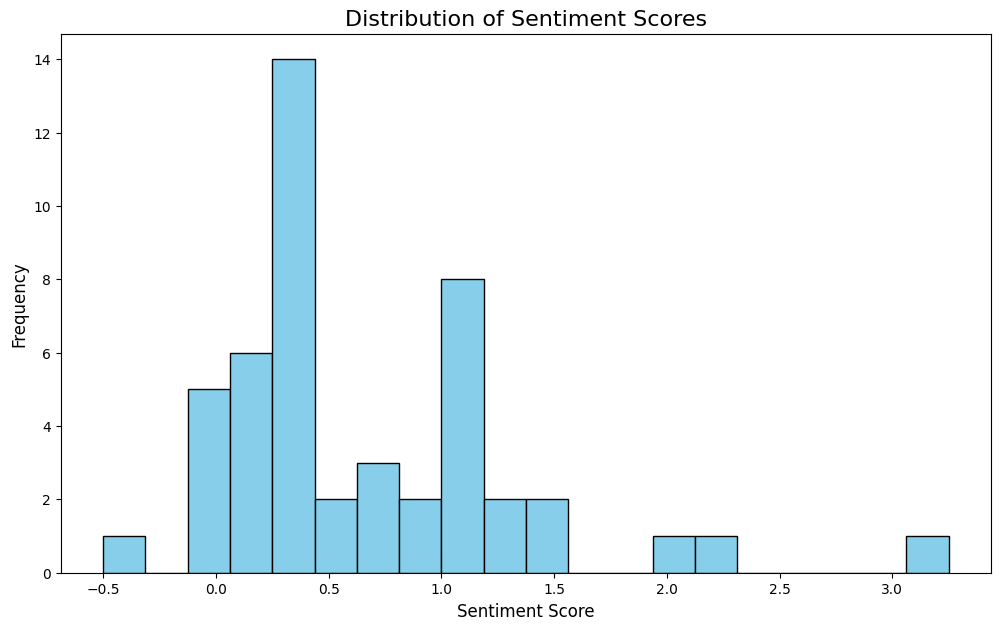

In [179]:
plt.figure(figsize=(12, 7))
plt.hist(df['AI_benefit_sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sentiment Scores', fontsize=16)

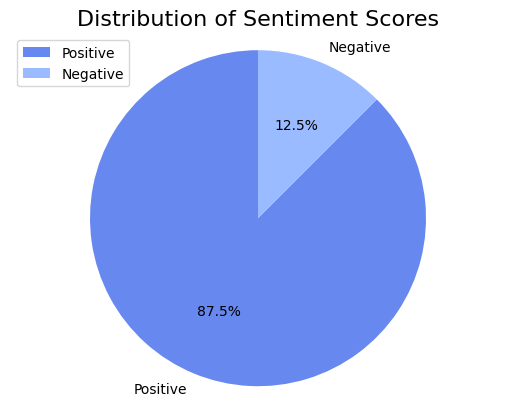

In [180]:
plt.pie(df['AI_benefit_sentiment'].value_counts(), labels=df['AI_benefit_sentiment'].value_counts().index, colors=sns.color_palette("coolwarm"), autopct='%1.1f%%', startangle=90)
plt.legend(labels=df['AI_benefit_sentiment'].value_counts().index)
plt.title('Distribution of Sentiment Scores', fontsize=16)
plt.axis('equal')
plt.show()

In [181]:
# Question 10 word tokenization
lemmatizer = WordNetLemmatizer()

future_education_texts = []

for text_entry in df['AI_future_education']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    future_education_texts.append(filtered_and_lemmatized_tokens)

In [182]:
# Question 10 sentiment result
future_education_sentiment = []

for text in future_education_texts:
  pos = 0
  neg = 0
  for word in text:
    if word in senti_word_net:
      pos += senti_word_net[word]['PosScore']
      neg += senti_word_net[word]['NegScore']
  future_education_sentiment.append(pos-neg)


df['AI_future_education_sentiment_score'] = future_education_sentiment
df['AI_future_education_sentiment'] = ['Positive' if score > 0 else 'Negative' for score in future_education_sentiment]

Text(0.5, 1.0, 'Distribution of Sentiment Scores')

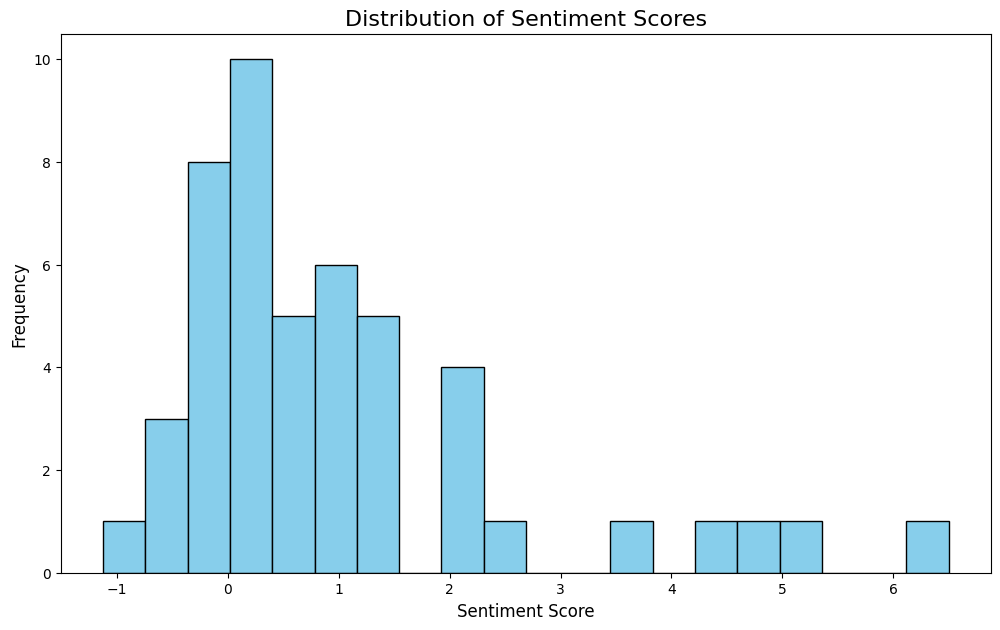

In [183]:
plt.figure(figsize=(12, 7))
plt.hist(df['AI_future_education_sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sentiment Scores', fontsize=16)

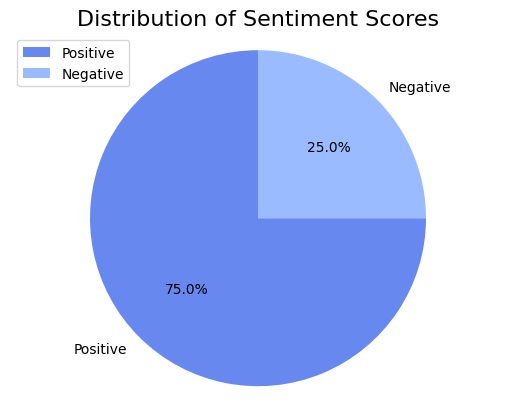

In [184]:
plt.pie(df['AI_future_education_sentiment'].value_counts(), labels=df['AI_future_education_sentiment'].value_counts().index, colors=sns.color_palette("coolwarm"), autopct='%1.1f%%', startangle=90)
plt.legend(labels=df['AI_future_education_sentiment'].value_counts().index)
plt.title('Distribution of Sentiment Scores', fontsize=16)
plt.axis('equal')
plt.show()

In [185]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_education = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    ngram_range=(1, 2)
)

tfidf_vectorizer_important = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    ngram_range=(1, 2)
)

tfidf_education_matrix = tfidf_vectorizer_education.fit_transform(processed_benefit_texts)
tfidf_important_education_matrix = tfidf_vectorizer_important.fit_transform(processed_future_education_texts)

In [186]:
# Question 9 LDA Result
from sklearn.cluster import KMeans

num_clusters = 3

km = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
km.fit(tfidf_education_matrix)

cluster_labels = km.labels_

feature_names = tfidf_vectorizer_education.get_feature_names_out()

order_centroids = km.cluster_centers_.argsort()[:, ::-1]
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_terms = [feature_names[ind] for ind in order_centroids[i, :10]]
    print("\t" + ", ".join(top_terms))

    print("\n\tSample documents:")
    sample_documents_indices = [idx for idx, label in enumerate(cluster_labels) if label == i]
    for doc_idx in sample_documents_indices[:3]:
        print(f"\t- {processed_education_texts[doc_idx]}")




Cluster 0:
	time, good, time reduction, reduction, diverse, time saving, saving, reduce, reduce time, coding

	Sample documents:
	- get good insight
	- save time make work easier
	- time reduction

Cluster 1:
	convenient, time saving, time reduction, time, utilization, thought, thinking, task, think, saving

	Sample documents:
	- convenient
	- convenient
	- convenient

Cluster 2:
	information, convenience, task, efficiency, quickly, homework, thinking, idea, collection, help

	Sample documents:
	- whether accurate allows quick efficient information retrieval utilization
	- convenience
	- 


/tmp/ipykernel_28097/3258925421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


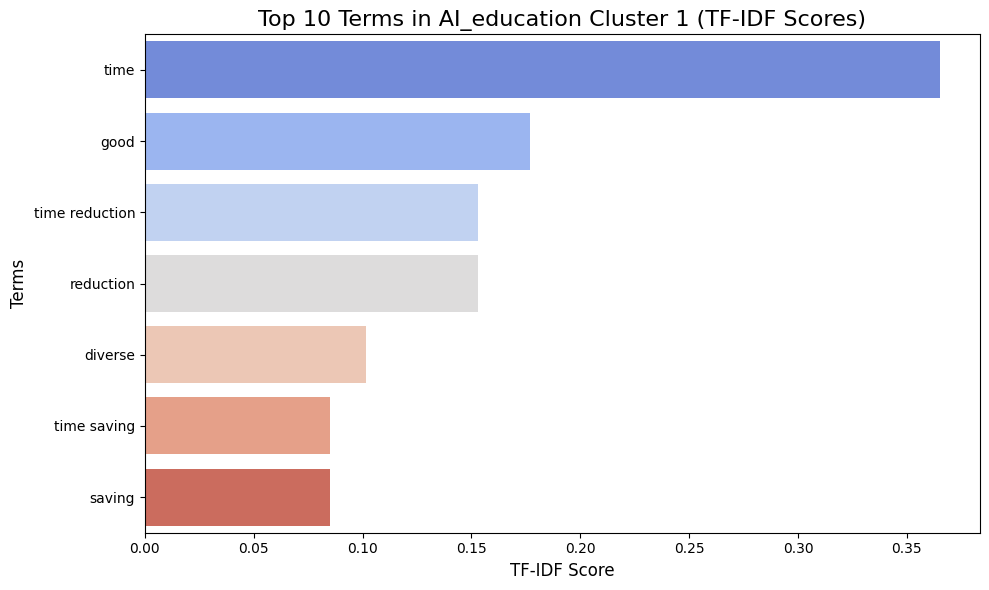

/tmp/ipykernel_28097/3258925421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


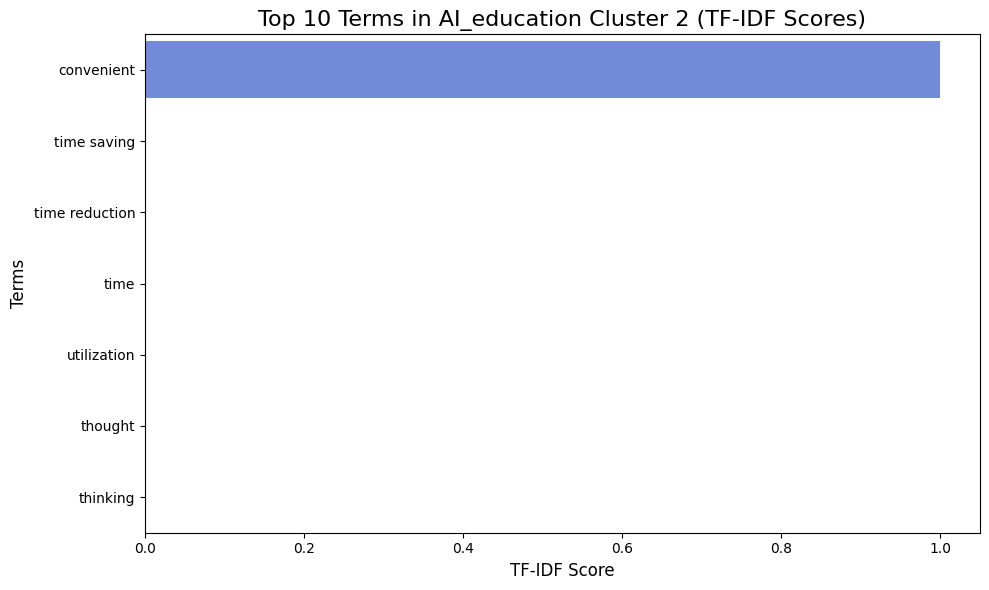

/tmp/ipykernel_28097/3258925421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


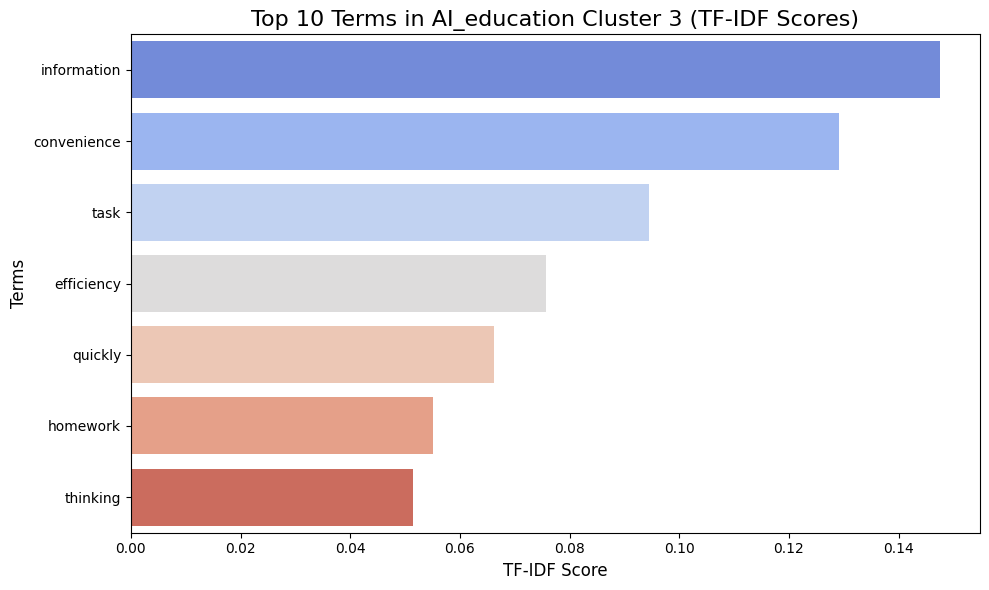

In [187]:
num_clusters_education = num_clusters
feature_names_education = feature_names
order_centroids_education = order_centroids

for i in range(num_clusters_education):
    top_term_indices = order_centroids_education[i, :7]

    top_terms = [feature_names_education[ind] for ind in top_term_indices]
    top_term_scores = km.cluster_centers_[i, top_term_indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')

    plt.title(f'Top 10 Terms in AI_education Cluster {i+1} (TF-IDF Scores)', fontsize=16)
    plt.xlabel('TF-IDF Score', fontsize=12)
    plt.ylabel('Terms', fontsize=12)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_28097/2024161830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts_education.index, y=cluster_counts_education.values, palette="plasma")


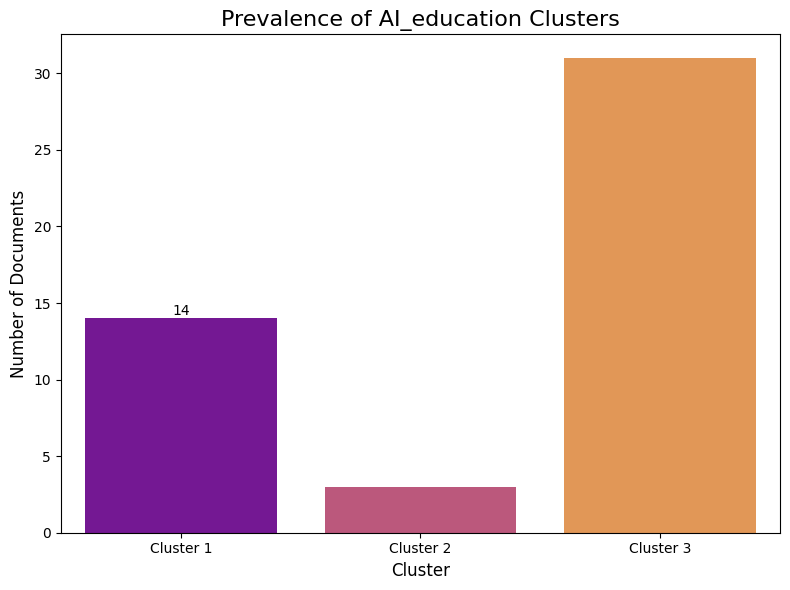

In [188]:
cluster_labels_education = km.labels_
cluster_counts_education = pd.Series(cluster_labels_education).value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=cluster_counts_education.index, y=cluster_counts_education.values, palette="plasma")
plt.title('Prevalence of AI_education Clusters', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(ticks=cluster_counts_education.index, labels=[f'Cluster {i+1}' for i in cluster_counts_education.index])
plt.bar_label(plt.gca().containers[0])
plt.tight_layout()
plt.show()

In [189]:
# Question 10 LDA Result
from sklearn.cluster import KMeans

num_clusters = 3

km = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
km.fit(tfidf_important_education_matrix)

cluster_labels = km.labels_

feature_names = tfidf_vectorizer_important.get_feature_names_out()

order_centroids = km.cluster_centers_.argsort()[:, ::-1]
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_terms = [feature_names[ind] for ind in order_centroids[i, :10]]
    print("\t" + ", ".join(top_terms))

    print("\n\tSample documents:")
    sample_documents_indices = [idx for idx, label in enumerate(cluster_labels) if label == i]
    for doc_idx in sample_documents_indices[:3]:
        print(f"\t- {processed_future_education_texts[doc_idx]}")



Cluster 0:
	ai, student, think, relying, use, get, studying, dependence, dependence ai, study

	Sample documents:
	- think get rid pointless job
	- think many class related ai future
	- think allow people learn different perspective without studying people also allows people understand interpret develop concept easily

Cluster 1:
	change, improve, education, negative, based, use ai, use, ai, essential, seems

	Sample documents:
	- depends used think high possibility change negative direction
	- comfortably
	- improve idea

Cluster 2:
	education, seems, like, seems like, information, higher education, higher, decline, used, college

	Sample documents:
	- seems like number enrollment higher education institute gradually decline
	- seems like reduce burden college graduate student
	- seems like increase efficiency education allowing information acquired utilized short time


/tmp/ipykernel_28097/698283257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


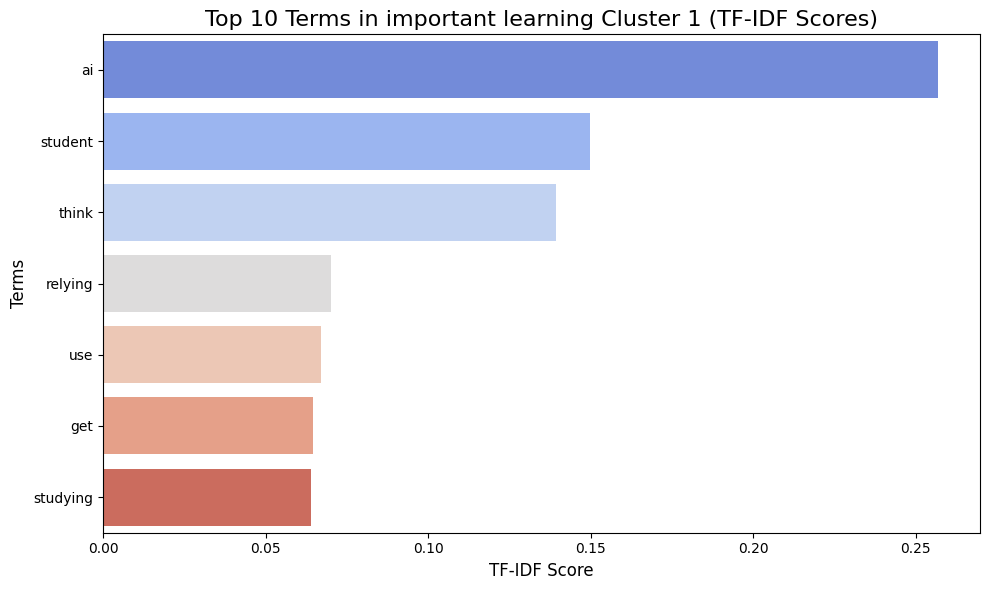

/tmp/ipykernel_28097/698283257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


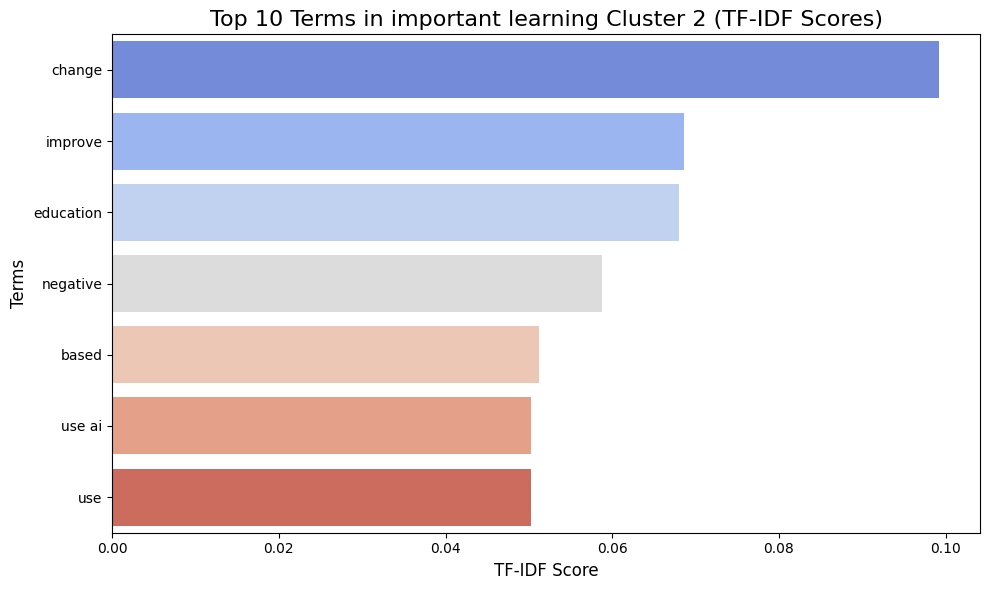

/tmp/ipykernel_28097/698283257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


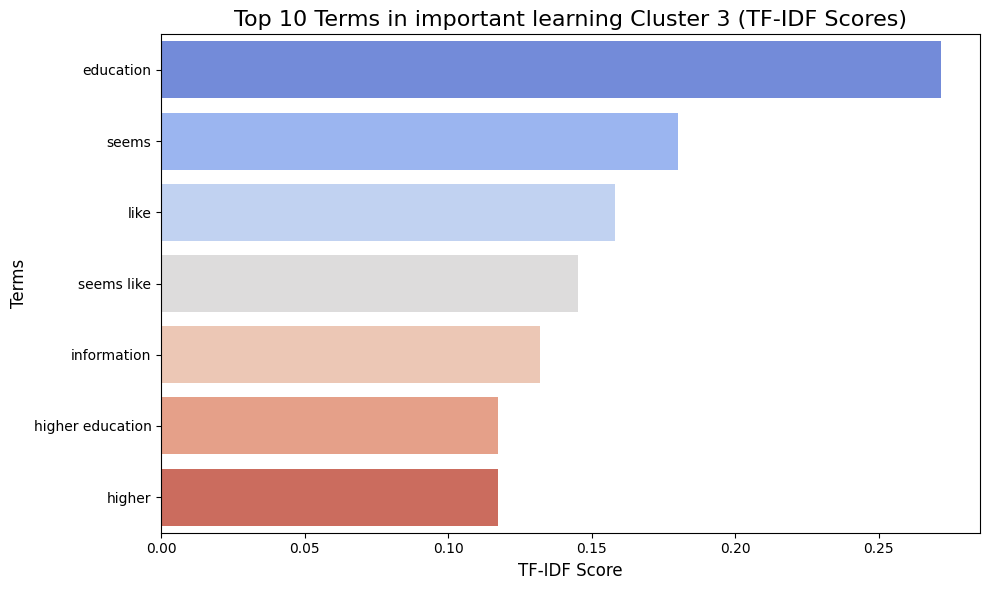

In [190]:
num_clusters_important_education = num_clusters
feature_names_important_education = feature_names
order_centroids_important_education = order_centroids

for i in range(num_clusters_important_education):
    top_term_indices = order_centroids_important_education[i, :7]

    top_terms = [feature_names_important_education[ind] for ind in top_term_indices]
    top_term_scores = km.cluster_centers_[i, top_term_indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')

    plt.title(f'Top 10 Terms in important learning Cluster {i+1} (TF-IDF Scores)', fontsize=16)
    plt.xlabel('TF-IDF Score', fontsize=12)
    plt.ylabel('Terms', fontsize=12)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_28097/3731657012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts_important_education.index, y=cluster_counts_important_education.values, palette="plasma")


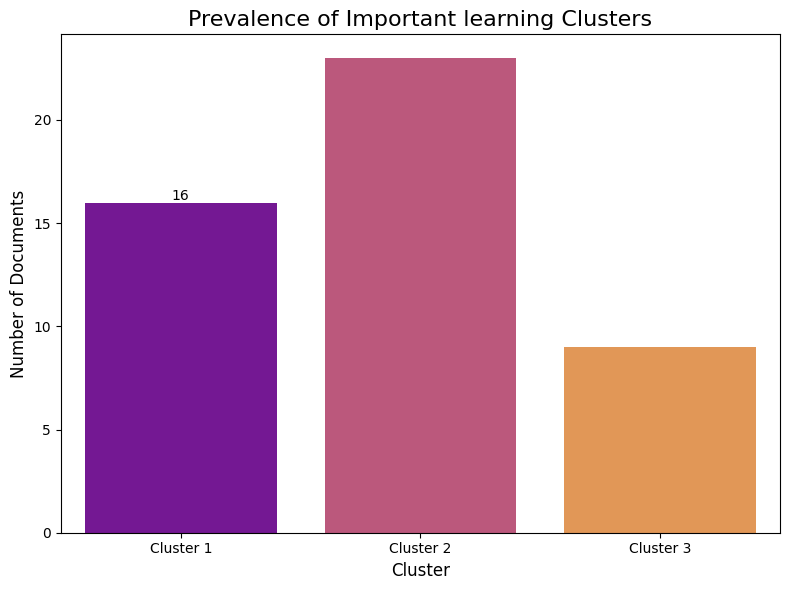

In [191]:
cluster_labels_important_education = km.labels_
cluster_counts_important_education = pd.Series(cluster_labels_important_education).value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=cluster_counts_important_education.index, y=cluster_counts_important_education.values, palette="plasma")
plt.title('Prevalence of Important learning Clusters', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(ticks=cluster_counts_important_education.index, labels=[f'Cluster {i+1}' for i in cluster_counts_important_education.index])
plt.bar_label(plt.gca().containers[0])
plt.tight_layout()
plt.show()

# Task
Perform sentiment analysis on the `AI_benefit` and `AI_future_education` columns of the DataFrame using the `SentiWordNet_3.0.0.txt` lexicon. This involves loading the lexicon, preparing the text data, implementing a sentiment scoring function, applying it to the specified columns to create new sentiment columns, and visualizing the sentiment distribution (positive, negative, neutral). Finally, provide a summary of the sentiment analysis results for both columns, highlighting the predominant sentiments.

## Load SentiWordNet Lexicon

### Subtask:
Load the SentiWordNet_3.0.0.txt file and parse it into a dictionary or a suitable data structure that allows easy lookup of positive, negative, and objective scores for words.


**Reasoning**:
I will load the SentiWordNet_3.0.0.txt file from the specified path, parse its contents, and store the positive and negative scores for each term in a dictionary named `senti_word_net`. Finally, I will print the first five entries of the dictionary to demonstrate that the lexicon has been loaded successfully.



In [192]:
senti_word_net_path = '/content/drive/MyDrive/Colab Notebooks/SentiWordNet_3.0.0.txt'
senti_word_net = {}

with open(senti_word_net_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue

        parts = line.split('\t')
        if len(parts) < 6:
            continue

        pos = parts[0]
        synset_id = parts[1]
        pos_score = float(parts[2])
        neg_score = float(parts[3])
        synset_terms_str = parts[4]

        synset_terms = synset_terms_str.split(' ')
        for term_entry in synset_terms:
            term = term_entry.split('#')[0].strip()
            if term:
                if term not in senti_word_net:
                    senti_word_net[term] = []
                senti_word_net[term].append({'PosScore': pos_score, 'NegScore': neg_score})

print("First 5 entries of senti_word_net:")
count = 0
for term, scores in senti_word_net.items():
    if count >= 5:
        break
    print(f"  {term}: {scores}")
    count += 1

First 5 entries of senti_word_net:
  able: [{'PosScore': 0.125, 'NegScore': 0.0}, {'PosScore': 0.125, 'NegScore': 0.0}, {'PosScore': 0.125, 'NegScore': 0.0}, {'PosScore': 0.25, 'NegScore': 0.0}]
  unable: [{'PosScore': 0.0, 'NegScore': 0.75}, {'PosScore': 0.0, 'NegScore': 0.375}, {'PosScore': 0.125, 'NegScore': 0.25}]
  dorsal: [{'PosScore': 0.0, 'NegScore': 0.0}, {'PosScore': 0.0, 'NegScore': 0.0}]
  abaxial: [{'PosScore': 0.0, 'NegScore': 0.0}]
  ventral: [{'PosScore': 0.0, 'NegScore': 0.0}, {'PosScore': 0.0, 'NegScore': 0.0}]


**Reasoning**:
The next logical step is to preprocess the text data in the 'AI_benefit' and 'AI_future_education' columns. This involves tokenization, removing stopwords and punctuation, and lemmatization, which is crucial before applying sentiment analysis using the SentiWordNet lexicon.



In [193]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]
    return ' '.join(filtered_and_lemmatized_tokens)

print("Preprocessing 'AI_benefit' column...")
df['AI_benefit_processed'] = df['AI_benefit'].apply(preprocess_text)

print("Preprocessing 'AI_future_education' column...")
df['AI_future_education_processed'] = df['AI_future_education'].apply(preprocess_text)

print("First 5 processed texts for 'AI_benefit_processed':")
for text in df['AI_benefit_processed'].head():
    print(f"  - {text}")

print("\nFirst 5 processed texts for 'AI_future_education_processed':")
for text in df['AI_future_education_processed'].head():
    print(f"  - {text}")

Preprocessing 'AI_benefit' column...
Preprocessing 'AI_future_education' column...
First 5 processed texts for 'AI_benefit_processed':
  - whether accurate allows quick efficient information acquisition utilization
  - convenience
  - get good insight
  - 
  - verification thought

First 5 processed texts for 'AI_future_education_processed':
  - depends used think high possibility change negative direction
  - comfortably
  - think get rid pointless job
  - improve idea
  - 


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
